# W06 · Policy-Gradient RL — REINFORCE, PPO and a GRPO-Style Group Baseline

Hongyu LIU · InGen Dynamics — ML & NN Analyst Intern, July 2026

**Platform:** Aido Rover (patrol / anomaly-response policy) · Origami / PIC 2.0 (GRPO)  
**Protocol:** 5 train seeds (0–4) × 10 fixed evaluation world seeds · canonical γ = 0.99, γ = 0.999 as a named ablation arm
**Deployment gates:** ≤100 ms patrol inference, ≤50 ms motion planning

Week 5 established the environment and value-based baselines. This notebook trains policy-gradient
methods on the same environment, adds the group-relative variant the PIC 2.0 GRPO class uses, and
evaluates everything under a protocol Week 5 did not have. Training runs through
`rl/harness/run_sweep.py`, which fans 96 jobs across cores; this notebook loads what those runs wrote
and does the analysis.

In [1]:
import json, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')
torch.set_num_threads(1)

from shared_modules.rl_eval import ART_DIR, EVAL_WORLD_SEEDS, W5_EVAL_SEEDS, N_TRAIN_SEEDS, \
    W6_TIMESTEPS, GAMMA, verify_w5_reference_gate, paired_test

SEED = 42
BLUE, ORANGE, GREEN, RED, GREY = '#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8C8C8C'
IMG_DIR = Path('../reports/image/W06_PolicyGradient_RL'); IMG_DIR.mkdir(parents=True, exist_ok=True)


def save(fig, name):
    fig.savefig(IMG_DIR / name, bbox_inches='tight', dpi=130)

## 1. Evaluation Protocol

Week 5 reported `mean ± std` over five seeds, but the ± mixed world-seed variance for the fixed
reference policies with train-seed variance for DQN, and it compared total return across policies
whose episodes ran 3,600 to 9,500 steps. Week 6 separates them: five **train seeds** per family
evaluated on ten fixed **evaluation world seeds**, with a family's paired vector taken as the
per-world mean across train seeds.

**Ten worlds is the minimum that permits a significant result.** A two-sided Wilcoxon signed-rank test
on `n` paired samples cannot return a p-value below `2/2ⁿ`. At `n = 5` the floor is 0.0625, so Week 5's
protocol could not have produced a significant comparison at any effect size. Ten worlds put it at
0.002.

The first five worlds are Week 5's own, so the Week-5 figures are recoverable as a subset. The gate
below re-evaluates the two bracket policies on those worlds and asserts they still reproduce the
published numbers; they existed in Week 5 only as closures duplicated inside two notebooks, and are
now one definition in `shared_modules/rl_eval.py`.

In [2]:
print('eval worlds  ', EVAL_WORLD_SEEDS)
print('train seeds  ', N_TRAIN_SEEDS, '| budget', f'{W6_TIMESTEPS:,}', 'env steps | gamma', GAMMA)
print('min attainable Wilcoxon p:  n=5 →', 2 / 2**5, '  n=10 →', 2 / 2**10)
pd.DataFrame(verify_w5_reference_gate()).T

eval worlds   [0, 1, 2, 3, 4, 101, 202, 303, 404, 505]
train seeds   5 | budget 250,000 env steps | gamma 0.99
min attainable Wilcoxon p:  n=5 → 0.0625   n=10 → 0.001953125


,published,reproduced,ok
scripted_blind,"(4072.02, 516.1, 9529.6)","(4072.02, 516.1, 9529.6)",True
expert_aware,"(12199.24, 736.02, 9367.2)","(12199.24, 736.02, 9367.2)",True


## 2. The Policy-Gradient Estimator

All four methods optimise `J(θ) = E_τ[Σ_t γᵗ r_t]` and differ only in the estimator

`∇_θ J(θ) = E_τ [ Σ_t ∇_θ log π_θ(a_t | s_t) · Ψ_t ]`

and in how they control its variance.

| method | `Ψ_t` | variance control |
| --- | --- | --- |
| REINFORCE | `G_t`, discounted return-to-go | none; variance grows with the horizon |
| REINFORCE + baseline | `G_t − V_φ(s_t)` | state-dependent baseline, per timestep |
| PPO | GAE-λ advantage with a clipped ratio | bootstrapped critic plus a trust region |
| GRPO-style | `(R_i − mean_G R)/std_G R`, constant over trajectory `i` | a group of trajectories replaces the critic |

**A baseline is free.** For any `b(s_t)` independent of the action,
`E_{a∼π}[∇_θ log π_θ(a|s_t)·b(s_t)] = b(s_t)·∇_θ Σ_a π_θ(a|s_t) = b(s_t)·∇_θ 1 = 0`. Subtracting it
leaves the gradient unbiased while removing the component of `G_t` shared by every action in that
state, which on this task is most of the signal: patrolling pays a nearly constant +0.95 per step
whatever action is chosen.

**Where GRPO differs structurally.** PPO's baseline is `V_φ(s_t)`, evaluated at every timestep. GRPO's
is the mean return of a group sampled from the *same* start state, and the advantage is one scalar
broadcast across the whole trajectory. The prediction stated before running: competitive on short
segments, coarser credit as segments lengthen.

Each GRPO update reaches one start state, `deepcopy`s the environment `G = 8` times and samples eight
trajectories of 256 steps from that identical state, matching PPO's 2,048 environment steps per update.
Half the groups start at an event-proximal state, because a 256-step segment with no bootstrap has an
effective horizon of 256 steps and a blockage sits ~1,500 steps beyond an ordinary reset.

## 3. Where the Methods Land

In [3]:
def load_eval(path=None):
    return json.loads(Path(path or ART_DIR / 'w6_eval.json').read_text())


# Display order and labels; the two bracket policies stay adjacent to the learned families they
# bracket so the table reads as a ladder rather than an alphabetical list.
DISPLAY = [
    ('random', 'random (no-abort)'),
    ('reinforce', 'REINFORCE'),
    ('reinforce_baseline', 'REINFORCE + value baseline'),
    ('ppo250k', 'PPO 250k'),
    ('grpo250k', 'GRPO-style 250k'),
    ('ppo250k_g999', 'PPO 250k, γ = 0.999'),
    ('dqn_ew0.05', 'DQN 80k (Week 5)'),
    ('dqn250k_raw', 'DQN 250k (W5 config, slower ε anneal)'),
    ('dqn250k', 'DQN 250k (normalised obs)'),
    ('scripted_blind', 'scripted, label-blind (floor)'),
    ('bc_offline', 'BC (offline)'),
    ('reinforce_baseline_bcinit', 'REINFORCE + baseline, BC-init'),
    ('ppo250k_bcinit', 'PPO 250k, BC-init'),
    ('grpo250k_bcinit', 'GRPO-style 250k, BC-init'),
    ('ppo_g999_bcinit', 'PPO 250k, γ = 0.999, BC-init'),
    ('expert_aware', 'expert, label-aware (ceiling)'),
]


def _f(v, nd=2):
    return '—' if v is None or (isinstance(v, float) and v != v) else f'{v:.{nd}f}'


def headline_table(ev, order=None):
    """Return-per-step and event-conditioned rates; raw return is kept but is not the headline."""
    rows = []
    for tag, label in (order or DISPLAY):
        d = ev.get(tag)
        if d is None:
            continue
        rows.append({
            'policy': label,
            'return': f"{d['return_mean']:.0f} ± {d['return_std']:.0f}",
            'ret/step': f"{d['ret_per_step_mean']:.3f}",
            'ep len': f"{d['len_mean']:.0f}",
            'P(alert|anom)': _f(d.get('p_alert_anomaly')),
            'false alerts /1k': _f(d.get('false_alerts_per_1k'), 1),
            'P(reroute|block)': _f(d.get('p_reroute_block')),
            'P(slow|rough)': _f(d.get('p_slow_rough')),
            'dock rate': _f(d.get('dock_rate')),
            'latency ms': _f(d.get('latency_ms'), 3),
        })
    return pd.DataFrame(rows)


ev = load_eval()
headline_table(ev)

,policy,return,ret/step,ep len,P(alert|anom),false alerts /1k,P(reroute|block),P(slow|rough),dock rate,latency ms
0,random (no-abort),-976 ± 501,-0.157,5837,0.24,249.9,0.26,0.26,—,0.001
1,REINFORCE,1579 ± 789,0.518,3163,0.49,137.3,0.01,0.01,—,0.027
2,REINFORCE + value baseline,1329 ± 694,0.398,3430,0.32,76.0,0.08,0.11,—,0.027
3,PPO 250k,156 ± 17,0.517,309,0.00,0.0,—,—,—,0.120
4,GRPO-style 250k,214 ± 33,0.673,322,0.25,26.8,—,—,—,0.027
5,"PPO 250k, γ = 0.999",135 ± 1,0.431,332,0.00,0.3,—,—,—,0.120
6,DQN 80k (Week 5),2651 ± 480,0.392,6418,0.40,164.9,0.01,0.55,—,0.068
7,"DQN 250k (W5 config, slower ε anneal)",2048 ± 648,0.314,5983,0.60,319.2,0.09,0.26,—,0.068
8,DQN 250k (normalised obs),2461 ± 520,0.431,5794,0.57,226.9,0.04,0.34,—,0.072
9,"scripted, label-blind (floor)",3931 ± 616,0.438,9009,0.00,3.7,1.00,0.94,—,0.001


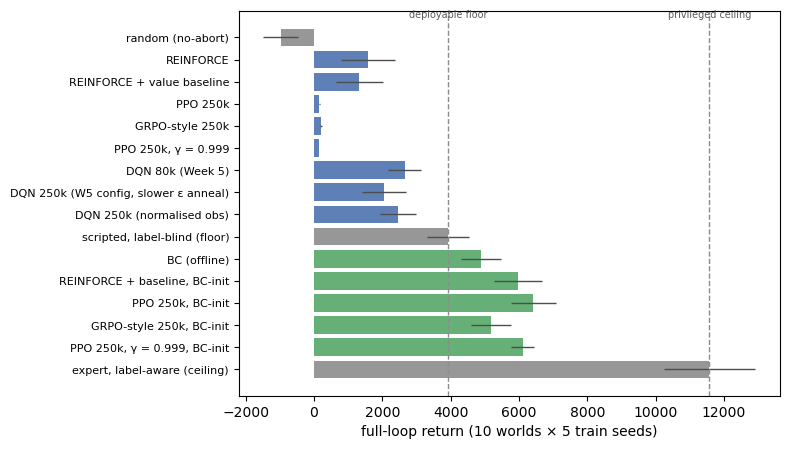

In [4]:
def fig_ladder(ev):
    """Return by policy, with the deployable floor and privileged ceiling as vertical bounds."""
    order = [t for t, _ in DISPLAY if t in ev]
    labels = dict(DISPLAY)
    vals = [ev[t]['return_mean'] for t in order]
    errs = [ev[t]['return_std'] for t in order]
    ref = {'random', 'scripted_blind', 'expert_aware'}
    cols = [GREY if t in ref else GREEN if t.endswith('bcinit') or t == 'bc_offline' else BLUE
            for t in order]
    fig, ax = plt.subplots(figsize=(8, 4.6))
    ax.barh(range(len(order)), vals, xerr=errs, color=cols, alpha=0.9,
            error_kw=dict(lw=1, ecolor='0.3'))
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([labels[t] for t in order], fontsize=8)
    for x, lab in [(ev['scripted_blind']['return_mean'], 'deployable floor'),
                   (ev['expert_aware']['return_mean'], 'privileged ceiling')]:
        ax.axvline(x, ls='--', color=GREY, lw=1)
        ax.text(x, -0.9, lab, fontsize=7, color='0.35', ha='center')
    ax.set_xlabel('full-loop return (10 worlds × 5 train seeds)')
    ax.invert_yaxis()
    fig.tight_layout()
    save(fig, 'return_ladder.png')
    return fig


fig_ladder(ev); plt.show()

The ladder splits into three bands. Every from-scratch on-policy method sits near zero, the value-based
agents reach 2,000–2,700 below the rule-policy floor, and every warm-started method clears the floor.

Total return hides what separates the top band, so the next figure plots the two behaviours the
platform cares about.

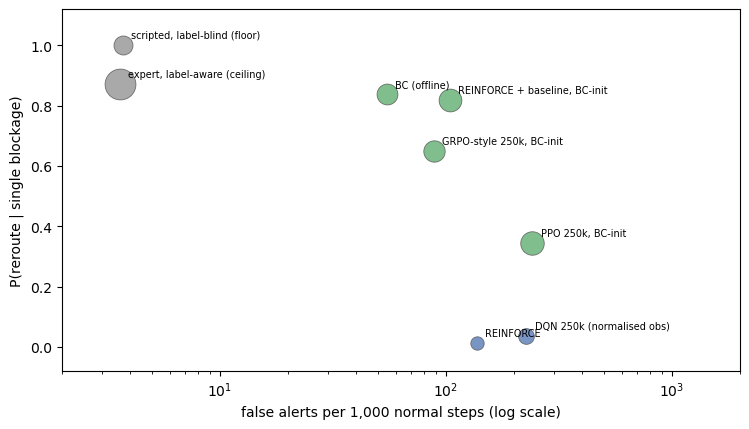

In [5]:
def fig_behaviour(ev):
    """False-alarm load against navigational competence; return is the marker size."""
    pick = ['dqn250k', 'reinforce', 'ppo250k_bcinit', 'grpo250k_bcinit',
            'reinforce_baseline_bcinit', 'bc_offline', 'scripted_blind', 'expert_aware']
    labels = dict(DISPLAY)
    fig, ax = plt.subplots(figsize=(7.6, 4.4))
    for t in pick:
        d = ev.get(t)
        if not d or d.get('p_reroute_block') is None:
            continue
        c = GREY if t in ('scripted_blind', 'expert_aware') else \
            GREEN if t.endswith('bcinit') or t == 'bc_offline' else BLUE
        ax.scatter(max(d['false_alerts_per_1k'], 0.5), d['p_reroute_block'],
                   s=30 + d['return_mean'] / 25, color=c, alpha=0.75, edgecolor='0.3', lw=0.6)
        ax.annotate(labels.get(t, t), (max(d['false_alerts_per_1k'], 0.5), d['p_reroute_block']),
                    textcoords='offset points', xytext=(6, 5), fontsize=7)
    ax.set_xscale('log')
    ax.set_xlim(2, 2000)
    ax.set_xlabel('false alerts per 1,000 normal steps (log scale)')
    ax.set_ylabel('P(reroute | single blockage)')
    ax.set_ylim(-0.08, 1.12)
    fig.tight_layout()
    save(fig, 'behaviour_profile.png')
    return fig


fig_behaviour(ev); plt.show()

PPO returns the most and reroutes the least of the warm-started three. Its fine-tuning takes rerouting
from the behaviour-cloning prior's 0.84 down to 0.34 while pushing alert recall from 0.21 to 0.85 and
the false-alarm rate from 55 to 241 per 1,000 normal steps. The GRPO implementation carries a KL
penalty to the frozen BC reference and retains 0.65; REINFORCE with a baseline retains 0.82.

## 4. The Warm Start Is a Precondition

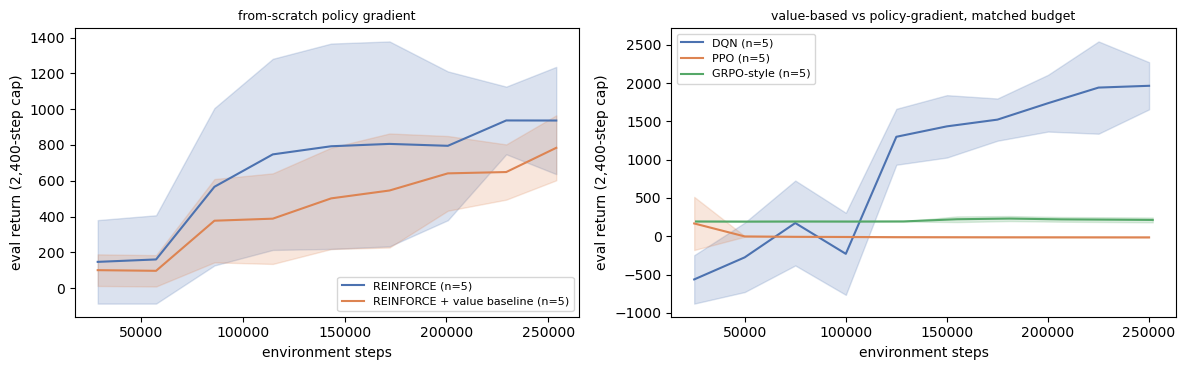

In [6]:
def load_curves(tag, n_seeds=5):
    """Learning curves from the per-seed training metas, aligned on the shortest run."""
    ts, res = None, []
    for s in range(n_seeds):
        p = ART_DIR / f'{tag}_s{s}_meta.json'
        if not p.exists():
            continue
        c = json.loads(p.read_text()).get('curve') or {}
        if not c.get('results'):
            continue
        ts = c['timesteps'] if ts is None else ts
        res.append(c['results'])
    if not res:
        return None, None
    k = min(len(r) for r in res)
    return np.array(ts[:k]), np.array([r[:k] for r in res])


def plot_curves(tags, labels, ax, colors=None):
    colors = colors or [BLUE, ORANGE, GREEN, RED, GREY]
    for i, tag in enumerate(tags):
        ts, cur = load_curves(tag)
        if ts is None:
            continue
        m, sd = cur.mean(0), cur.std(0)
        ax.plot(ts, m, color=colors[i % len(colors)], label=f'{labels[i]} (n={len(cur)})')
        ax.fill_between(ts, m - sd, m + sd, alpha=0.2, color=colors[i % len(colors)])
    ax.set_xlabel('environment steps'); ax.set_ylabel('eval return (2,400-step cap)')
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plot_curves(['reinforce', 'reinforce_baseline'],
            ['REINFORCE', 'REINFORCE + value baseline'], axes[0])
axes[0].set_title('from-scratch policy gradient', fontsize=9)
plot_curves(['dqn250k', 'ppo250k', 'grpo250k'], ['DQN', 'PPO', 'GRPO-style'], axes[1])
axes[1].set_title('value-based vs policy-gradient, matched budget', fontsize=9)
plt.tight_layout(); save(fig, 'learning_curves.png'); plt.show()

In [7]:
# The collapse mechanism rests on what an untrained policy earns per step, and no table above
# measures that: the 'random' reference samples uniformly over the four non-terminating actions,
# not from fresh network weights. Measured here under training conditions — stochastic actions,
# randomized resets, the 2,400-step training cap.
from rl.pg_algos import PGPolicy
from rl.rover_env import RoverPatrolEnv
from shared_modules.rl_eval import NormalizeObs

per_step = []
for s in range(5):
    torch.manual_seed(s)
    pol = PGPolicy()
    env = NormalizeObs(RoverPatrolEnv(randomize_reset=True, seed=s))
    for _ in range(2):
        o, _ = env.reset()
        tot, n = 0.0, 0
        while n < 2400:
            o, r, term, trunc, _ = env.step(pol.act(o))
            tot += r
            n += 1
            if term or trunc:
                break
        per_step.append(tot / n)
    env.close()
per_step = np.array(per_step)
print(f'untrained-policy reward per step: {per_step.mean():.2f} ± {per_step.std():.2f} '
      f'(5 init seeds × 2 episodes)')

untrained-policy reward per step: -1.73 ± 1.15 (5 init seeds × 2 episodes)


PPO and the GRPO-style variant converge to patrolling for ~310 steps and then taking the terminating
action to bank a small positive return; two seeds produce bit-identical trajectories, which is what a
deterministic rule on a deterministic world gives. A random initial policy earns about −1.7 per step
(measured above), so ending the episode is genuinely better than continuing, and once the policy
shortens its episodes it stops collecting the long-horizon patrol data that would overturn that
estimate.

**The two methods that fall into this are the two with a clipped surrogate and a bootstrapped critic.**
Plain REINFORCE reaches 1,579 and DQN is immune through replay and ε-greedy. The high-variance
estimator's updates keep the policy moving through the region where terminating looks locally optimal.

The same code from a BC checkpoint reaches 6,421, which rules out an implementation defect.

In [8]:
def paired_matrix(ev, tags):
    """Wilcoxon signed-rank across the ten common evaluation worlds, for every listed pair."""
    rows = []
    for i, x in enumerate(tags):
        for y in tags[i + 1:]:
            if x not in ev or y not in ev:
                continue
            t = paired_test(ev[x]['per_world'], ev[y]['per_world'])
            rows.append(dict(A=x, B=y, **{'Δ return (A−B)': round(t['delta'], 1),
                                          'p': round(t['p'], 4),
                                          'significant': t['significant']}))
    return pd.DataFrame(rows)


paired_matrix(ev, ['bc_offline', 'scripted_blind', 'dqn250k', 'dqn_ew0.05', 'dqn250k_raw',
                   'ppo250k_bcinit', 'grpo250k_bcinit', 'reinforce_baseline_bcinit',
                   'ppo_g999_bcinit'])

,A,B,Δ return (A−B),p,significant
0,bc_offline,scripted_blind,961.2,0.0039,True
1,bc_offline,dqn250k,2430.5,0.0020,True
2,bc_offline,dqn_ew0.05,2240.7,0.0020,True
3,bc_offline,dqn250k_raw,2843.7,0.0020,True
4,bc_offline,ppo250k_bcinit,-1529.7,0.0371,True
5,bc_offline,grpo250k_bcinit,-290.6,0.1934,False
6,bc_offline,reinforce_baseline_bcinit,-1077.7,0.0020,True
7,bc_offline,ppo_g999_bcinit,-1212.4,0.1309,False
8,scripted_blind,dqn250k,1469.4,0.0039,True
9,scripted_blind,dqn_ew0.05,1279.5,0.0273,True


The budget question Week 5 left open closes in the `dqn_ew0.05` vs `dqn250k_raw` row: tripling the
budget with a slower ε anneal moves the paired return by −603 at `p = 0.084`, so Week 5's reading of
the navigational failure as structural stands and its report needs no revision.

The γ = 0.999 probe is a clean null (`p = 0.49`). With the route geometry measured, that is expected:
a blockage at the 150 m detection threshold sits 1,500 environment steps away at 0.1 m per step,
beyond a 1,000-step horizon.

## 5. Measuring the Group Baseline's Variance

A return curve cannot separate a low-variance estimator from a lucky one, so every update splits its
own transitions into two disjoint halves, computes the policy gradient on each, and records the cosine
similarity between the two vectors.

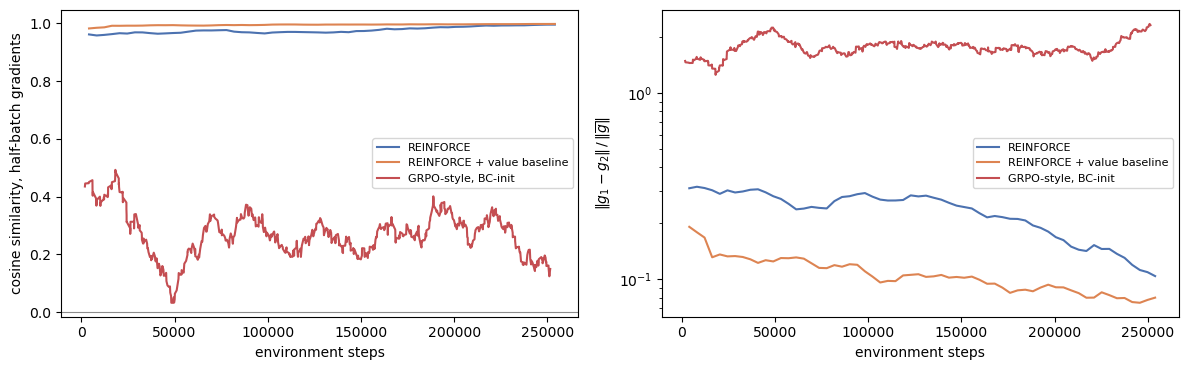

,method,updates,grad_cos,grad_rel_l2,advantage_var,group_return_std
0,REINFORCE,62,0.977,0.233,2.921,NaN
1,REINFORCE + value baseline,62,0.995,0.108,2.984,NaN
2,"GRPO-style, BC-init",126,0.265,1.786,0.970,5.954


In [9]:
def load_updates(tag, n_seeds=5):
    """Per-update instrumentation (advantage variance, gradient noise, KL) from the PG runs."""
    out = []
    for s in range(n_seeds):
        f = ART_DIR / f'{tag}_s{s}_meta.json'
        if f.exists():
            u = json.loads(f.read_text()).get('updates')
            if u:
                out.append(pd.DataFrame(u).assign(seed=s, tag=tag))
    return pd.concat(out, ignore_index=True) if out else None


PG_INSTRUMENTED = [('reinforce', 'REINFORCE', BLUE),
                   ('reinforce_baseline', 'REINFORCE + value baseline', ORANGE),
                   ('grpo250k_bcinit', 'GRPO-style, BC-init', RED)]

# GRPO takes ~127 updates against REINFORCE's 62, so both series are smoothed over a window
# proportional to their own length before being drawn on a shared axis.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
summary = []
for tag, lab, c in PG_INSTRUMENTED:
    u = load_updates(tag)
    if u is None:
        continue
    g = u.groupby('timesteps')[['grad_cos', 'grad_rel_l2']].mean().sort_index()
    w = max(3, len(g) // 12)
    axes[0].plot(g.index, g['grad_cos'].rolling(w, center=True, min_periods=1).mean(), color=c, label=lab)
    axes[1].plot(g.index, g['grad_rel_l2'].rolling(w, center=True, min_periods=1).mean(), color=c, label=lab)
    row = dict(method=lab, updates=len(u) // u.seed.nunique(),
               grad_cos=u.grad_cos.mean(), grad_rel_l2=u.grad_rel_l2.mean(),
               advantage_var=u.advantage_var.mean())
    if 'group_return_std' in u:
        row['group_return_std'] = u.group_return_std.mean()
    summary.append(row)
axes[0].set_ylabel('cosine similarity, half-batch gradients'); axes[0].axhline(0, color=GREY, lw=0.8)
axes[1].set_ylabel(r'$\|g_1-g_2\| \,/\, \|\overline{g}\|$'); axes[1].set_yscale('log')
for ax in axes:
    ax.set_xlabel('environment steps'); ax.legend(fontsize=8)
plt.tight_layout(); save(fig, 'gradient_variance.png'); plt.show()
pd.DataFrame(summary).round(3)

Raw gradient agreement has to be read together with what the advantage is. An uncentred return-to-go
makes both half-batches agree on the large common "raise the log-probability of whatever was done"
component, so REINFORCE scores high on cosine similarity while carrying no more usable signal. Centring
removes that component and exposes the disagreement in the direction that matters. The operational
stability measure is the seed spread of the learning curves above and the layout sweep in §6.

## 6. Generalisation Across Map Layouts

The Week-2 design report flags a check no week had run: a policy that only works on one procedurally
generated layout is over-fitted to it. Each family's seed-0 policy is re-evaluated without retraining
on the five other layouts the generator validated, five worlds each. Map seed 3 is absent because the
Week-2 generator could not calibrate its terrain exposure into the 14–16 % anomaly band.

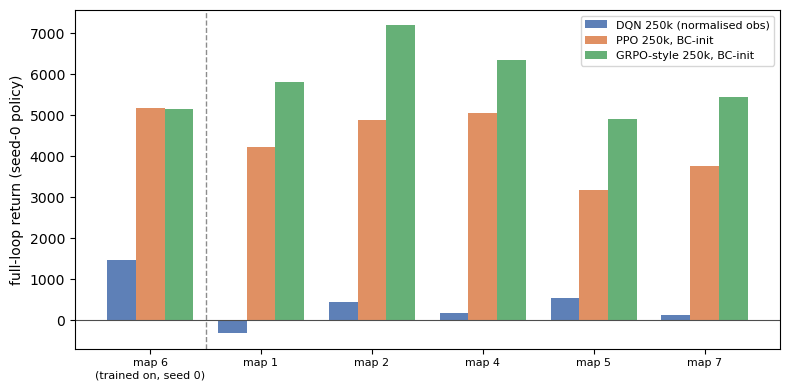

,policy,map 6 (canonical),map 6 (seed 0),map 1,map 2,map 4,map 5,map 7
0,DQN 250k (normalised obs),2461,1463,-316,443,167,539,118
1,"GRPO-style 250k, BC-init",5182,5157,5807,7193,6352,4902,5448
2,"PPO 250k, BC-init",6421,5170,4234,4893,5066,3186,3767


In [10]:
def fig_cross_layout(ev):
    """Return on the training layout against the five the policies never saw.

    The held-out evaluations exist for the seed-0 policy only, so the map-6 bar is that same
    seed's mean over the ten canonical worlds — one aggregation level across the whole chart,
    not the 5-seed family mean the tables elsewhere report.
    """
    pick = [('dqn250k', BLUE), ('ppo250k_bcinit', ORANGE), ('grpo250k_bcinit', GREEN)]
    labels = dict(DISPLAY)
    maps = sorted(ev['ppo250k_bcinit']['cross_map'], key=int)
    fig, ax = plt.subplots(figsize=(8, 4))
    w, x = 0.26, np.arange(len(maps) + 1)
    for i, (t, c) in enumerate(pick):
        d = ev[t]
        vals = [np.mean(d['per_seed'][0])] + [d['cross_map'][m]['return_mean'] for m in maps]
        ax.bar(x + (i - 1) * w, vals, w, color=c, alpha=0.9, label=labels[t])
    ax.axhline(0, color='0.3', lw=0.8)
    ax.axvline(0.5, color=GREY, ls='--', lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels(['map 6\n(trained on, seed 0)'] + [f'map {m}' for m in maps], fontsize=8)
    ax.set_ylabel('full-loop return (seed-0 policy)')
    ax.legend(fontsize=8)
    fig.tight_layout()
    save(fig, 'cross_layout.png')
    return fig


def cross_map_table(ev):
    """Generalisation across the W02-validated layouts other than the canonical MAP_SEED = 6.

    'map 6 (canonical)' is the published 5-seed family mean; 'map 6 (seed 0)' is the evaluated
    policy's own canonical score, the comparator for the held-out columns.
    """
    rows = []
    for tag, d in ev.items():
        if not isinstance(d, dict) or 'cross_map' not in d:
            continue
        r = {'policy': dict(DISPLAY).get(tag, tag),
             'map 6 (canonical)': round(d['return_mean']),
             'map 6 (seed 0)': round(float(np.mean(d['per_seed'][0])))}
        for ms, v in d['cross_map'].items():
            r[f'map {ms}'] = round(v['return_mean'])
        rows.append(r)
    return pd.DataFrame(rows)


fig_cross_layout(ev); plt.show()
cross_map_table(ev)

**The canonical ordering reverses.** PPO and GRPO are statistically tied on map 6 (`p = 0.084` above),
and on all five held-out layouts the group-relative policy is ahead, scoring above its own canonical
result — the seed-0 policy's 5,157 on the training layout — on four of them (only map 5 falls short).
PPO's seed-0 policy loses 2–38 % of its own canonical 5,170 off the training layout, and DQN does not
transfer at all.

The ordering follows from the behaviour profile in §3. PPO's canonical advantage comes from alerting at
241 false alarms per 1,000 normal steps, which is a policy tuned to where the faults sit on this
terrain. The group-relative variant keeps the navigational behaviour its prior gave it and carries it
to terrain it has not seen.

## 7. Deployment Latency

In [11]:
lat = pd.DataFrame([{'policy': dict(DISPLAY).get(k, k), 'latency (ms)': v['latency_ms']}
                    for k, v in ev.items()
                    if isinstance(v, dict) and v.get('latency_ms') is not None])
lat['100 ms patrol gate'] = np.where(lat['latency (ms)'] < 100, 'PASS', 'FAIL')
lat['50 ms motion gate'] = np.where(lat['latency (ms)'] < 50, 'PASS', 'FAIL')
lat.sort_values('latency (ms)').round(4)

,policy,latency (ms),100 ms patrol gate,50 ms motion gate
0,random (no-abort),0.0009,PASS,PASS
1,"scripted, label-blind (floor)",0.0014,PASS,PASS
18,"REINFORCE + baseline, BC-init",0.0266,PASS,PASS
16,REINFORCE,0.0267,PASS,PASS
17,REINFORCE + value baseline,0.0267,PASS,PASS
7,"GRPO-style 250k, BC-init",0.0268,PASS,PASS
6,GRPO-style 250k,0.0268,PASS,PASS
2,BC (offline),0.0309,PASS,PASS
5,DQN 80k (Week 5),0.0680,PASS,PASS
4,"DQN 250k (W5 config, slower ε anneal)",0.0682,PASS,PASS


## 8. Results Ledger

This notebook owns the Week-6 block of `rl/rl_results.csv` because it is the one place that loads all
three evaluation sources. The write replaces the existing `week == 6` rows, so re-executing the
notebook is idempotent and the Week-5 rows are never touched.

In [12]:
def load_option_evals():
    """Option-level results, which live in their own files because the env differs."""
    out = {}
    for p in ART_DIR.glob('evalopt_*.json'):
        d = json.loads(p.read_text())
        out[d['tag']] = d
    return out


def load_marl_evals(n_seeds=5):
    """Per-reward-mode multi-agent results, aggregated across train seeds."""
    out = {}
    for tag, _ in DISPLAY_MARL:
        ds = [json.loads((ART_DIR / f'{tag}_s{s}_meta.json').read_text())
              for s in range(n_seeds) if (ART_DIR / f'{tag}_s{s}_meta.json').exists()]
        if not ds:
            continue
        ev = [d['eval'] for d in ds]
        keys = [k for k in ev[0] if isinstance(ev[0][k], (int, float))]
        out[tag] = dict(tag=tag, n_train_seeds=len(ds),
                        **{k: float(np.mean([e[k] for e in ev])) for k in keys})
        # ledger convention: the +/- is the across-seed std of per-seed means, as for every
        # other family; the within-seed (world) spread stays available in the meta files
        out[tag]['team_return_std'] = float(np.std([e['team_return_mean'] for e in ev]))
    return out


def load_irl_evals():
    """The two recovered-reward policies, scored on the same 10-world protocol."""
    out = {}
    for fs, note in [('priv', 'privileged feature basis'), ('obs', 'observation-only feature basis')]:
        p = ART_DIR / f'irl_{fs}.json'
        if not p.exists():
            continue
        v = json.loads(p.read_text())['validation']['policy']
        out[f'irl_{fs}'] = dict(tag=f'irl_{fs}', n_train_seeds=1,
                                return_mean=v['return_mean'], return_std=v['return_std'],
                                len_mean=v.get('len_mean', float('nan')),
                                per_world=v.get('per_world', []),
                                p_alert_anomaly=v.get('p_alert_anomaly'),
                                false_alerts_per_1k=v.get('false_alerts_per_1k'),
                                p_reroute_block=v.get('p_reroute_block'),
                                p_slow_rough=v.get('p_slow_rough'))
    return out


DISPLAY_MARL = [
    ('marl_shared', 'independent PPO, shared team reward'),
    ('marl_difference', 'independent PPO, difference reward'),
]


# Ledger metadata per family: the training budget and env variant a row was produced under. The
# Week-5 rows keep their original schema; the Week-6 columns are appended, not substituted.
LEDGER_META = {
    'dqn_ew0.05': ('80000', 'canonical', 'Week-5 run, re-evaluated on the Week-6 10-world protocol'),
    'dqn250k_raw': ('250000', 'canonical', 'budget re-run: W5 config, eps anneal 0.5'),
    'dqn250k': ('250000', 'canonical+normobs', 'like-for-like baseline for PPO/GRPO'),
    'ppo250k': ('250000', 'canonical+normobs', ''),
    'ppo250k_bcinit': ('250000', 'canonical+normobs', 'BC warm start, critic warmup 10k'),
    'grpo250k': ('250000', 'canonical+normobs', 'group-relative baseline, G=8, segment 256'),
    'grpo250k_bcinit': ('250000', 'canonical+normobs', 'BC warm start = KL reference policy'),
    'reinforce': ('250000', 'canonical+normobs', 'no baseline'),
    'reinforce_baseline': ('250000', 'canonical+normobs', 'learned value baseline'),
    'ppo250k_g999': ('250000', 'gamma=0.999', 'discount-horizon probe, non-canonical gamma'),
    'ppo_g999_bcinit': ('250000', 'gamma=0.999+normobs', 'discount probe from the BC warm start'),
    'ppo_lowsoc_c0': ('250000', 'soc_init 18-30', 'low-SoC ablation control'),
    'ppo_lowsoc_c15': ('250000', 'soc_init 18-30, low_soc_penalty 1.5', 'low-SoC ablation'),
    'ppo_lowsoc_c0_bcinit': ('250000', 'soc_init 18-30, BC-init', 'low-SoC control, warm start'),
    'ppo_lowsoc_c15_bcinit': ('250000', 'soc_init 18-30, penalty 1.5, BC-init',
                              'low-SoC ablation, warm start'),
    'reinforce_baseline_bcinit': ('250000', 'canonical+normobs', 'value baseline, BC warm start'),
    'options_smdp': ('250000', 'node-level SMDP, gamma=0.99',
                     'isolates credit assignment; option controllers are scripted'),
    'options_smdp_g1': ('250000', 'node-level SMDP, gamma=1.0',
                        'isolates horizon; episode cap supplies the finite horizon'),
    'options_smdp_1m': ('1000000', 'node-level SMDP, gamma=0.99', 'decision-count sufficiency check'),
    'options_smdp_g1_1m': ('1000000', 'node-level SMDP, gamma=1.0', 'decision-count sufficiency check'),
    'scripted_option': ('0', 'node-level SMDP', 'hand-written option policy; privileged controller'),
    'options_lowsoc_c0': ('250000', 'SMDP, soc_init 18-30', 'low-SoC control at option level'),
    'options_lowsoc_c15': ('250000', 'SMDP, soc_init 18-30, low_soc_penalty 1.5',
                           'dock is one decision here'),
    'marl_shared': ('1000000', '2-agent, shared reward', 'independent PPO learners'),
    'marl_difference': ('1000000', '2-agent, difference reward', 'independent PPO learners'),
    'scripted_blind': ('0', 'canonical', 'deployable rule reference (floor)'),
    'expert_aware': ('0', 'canonical', 'privileged ceiling (uses ground-truth label)'),
    'bc_offline': ('39642 rows', 'canonical', 'behaviour cloning, retrained for the W6 protocol'),
    'random': ('0', 'canonical', 'reference'),
    'irl_priv': ('0', 'canonical', 'MaxEnt IRL, privileged basis: soft-optimal policy under the recovered reward'),
    'irl_obs': ('0', 'canonical', 'MaxEnt IRL, observation-only basis: soft-optimal policy under the recovered reward'),
}


def _r(v, nd=3):
    return None if v is None or (isinstance(v, float) and v != v) else round(v, nd)


def ledger_rows(ev, oe=None, me=None, ie=None, constraint_ms=100.0):
    """Week-6 rows for `rl/rl_results.csv`, with the added event-rate and protocol columns.

    Flat, option-level, multi-agent and IRL results are evaluated on different environments and
    stored separately; they are pooled here because the ledger is a per-policy record, with
    `env_variant` carrying which environment produced each row.
    """
    rows = []
    merged = dict(ev)
    merged.update(oe or {})
    merged.update(ie or {})
    # the multi-agent evaluation reports a team return over two rovers, under different keys
    for tag, d in (me or {}).items():
        merged[tag] = dict(d, return_mean=d['team_return_mean'], return_std=d['team_return_std'],
                           len_mean=d.get('env_steps_mean', float('nan')),
                           n_train_seeds=d['n_train_seeds'])
    for tag, d in merged.items():
        if not isinstance(d, dict) or 'return_mean' not in d:
            continue
        steps, variant, note = LEDGER_META.get(tag, ('', '', ''))
        lat = d.get('latency_ms')
        parts = tag.split('_')
        gamma = 1.0 if 'g1' in parts else 0.999 if any(p == 'g999' for p in parts) else 0.99
        rows.append(dict(
            week=6, policy=tag, task='rover_patrol', platform='Aido Rover', timesteps=steps,
            n_seeds=d['n_train_seeds'], gamma=gamma,
            eval_horizon=9600, eval_policy='deterministic',
            energy_weight=0.05, shaping_low_soc=True, alert_clears_block=False,
            return_mean=round(d['return_mean'], 2), return_std=round(d['return_std'], 2),
            len_mean=round(d.get('len_mean', float('nan')), 1),
            latency_ms=None if lat is None else round(lat, 4),
            constraint_ms=constraint_ms,
            verdict='' if lat is None else ('PASS' if lat < constraint_ms else 'FAIL'),
            env_variant=variant, eval_worlds=len(d.get('per_world', [])) or 10,
            n_train_seeds=d['n_train_seeds'],
            return_per_step=round(d['ret_per_step_mean'], 4) if 'ret_per_step_mean' in d else None,
            p_alert_anomaly=_r(d.get('p_alert_anomaly')),
            false_alerts_per_1k=_r(d.get('false_alerts_per_1k'), 1),
            p_reroute_block=_r(d.get('p_reroute_block')),
            p_slow_rough=_r(d.get('p_slow_rough')),
            dock_rate=_r(d.get('dock_rate')),
            dock_episode_rate=_r(d.get('dock_episode_rate')),
            soc_depleted_rate=_r(d.get('soc_depleted_rate')),
            low_soc_steps=_r(d.get('low_soc_steps'), 0),
            notes=note))
    return pd.DataFrame(rows)


def layout_sweep_rows(ev):
    """One row per held-out layout for each seed-0 policy the cross-map sweep evaluated.

    These are the §6 numbers; without them the week's ranking reversal has no ledger record."""
    rows = []
    for tag, d in ev.items():
        if not isinstance(d, dict) or 'cross_map' not in d:
            continue
        for ms, v in sorted(d['cross_map'].items(), key=lambda kv: int(kv[0])):
            rows.append(dict(
                week=6, policy=tag, task='rover_patrol', platform='Aido Rover',
                timesteps=LEDGER_META.get(tag, ('', '', ''))[0],
                n_seeds=1, gamma=0.99, eval_horizon=9600, eval_policy='deterministic',
                energy_weight=0.05, shaping_low_soc=True, alert_clears_block=False,
                return_mean=round(v['return_mean'], 2), return_std=_r(v.get('return_std'), 2),
                env_variant=f'layout sweep: map {ms}', eval_worlds=5, n_train_seeds=1,
                constraint_ms=100.0,
                notes='seed-0 policy re-evaluated without retraining on a held-out layout'))
    return pd.DataFrame(rows)


from shared_modules.rl_eval import LEDGER
old = pd.read_csv(LEDGER)
old = old[old.week != 6]                     # replace the Week-6 block; Week-5 rows are untouched
rows = pd.concat([ledger_rows(ev, oe=load_option_evals(), me=load_marl_evals(),
                              ie=load_irl_evals()),
                  layout_sweep_rows(ev)], ignore_index=True, sort=False)
pd.concat([old, rows], ignore_index=True, sort=False).to_csv(LEDGER, index=False)
print(f'week-5 rows kept {len(old)}  |  week-6 rows written {len(rows)}')
rows[['policy', 'env_variant', 'return_mean', 'n_seeds', 'p_reroute_block', 'latency_ms']]

week-5 rows kept 9  |  week-6 rows written 46


,policy,env_variant,return_mean,n_seeds,p_reroute_block,latency_ms
0,random,canonical,-976.32,1,0.260,0.0009
1,scripted_blind,canonical,3930.60,1,1.000,0.0014
2,bc_offline,canonical,4891.78,1,0.838,0.0309
3,expert_aware,canonical,11574.59,1,0.871,NaN
4,dqn250k,canonical+normobs,2461.25,5,0.038,0.0725
5,dqn250k_raw,canonical,2048.13,5,0.087,0.0682
6,dqn_ew0.05,canonical,2651.12,5,0.012,0.0680
7,grpo250k,canonical+normobs,213.84,5,NaN,0.0268
8,grpo250k_bcinit,canonical+normobs,5182.37,5,0.650,0.0268
9,ppo250k,canonical+normobs,155.97,5,NaN,0.1204
